## Tweet Emotion Recognition: Natural Language Processing with TensorFlow

## Task 1: Setup and Imports

1. Installing Hugging Face's nlp package
2. Importing libraries

In [62]:
!pip install nlp

In [63]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import nlp
import random
import datasets

def show_history(h):
    epochs_trained = len(h.history['loss'])
    plt.figure(figsize=(16, 6))

    plt.subplot(1, 2, 1)
    plt.plot(range(0, epochs_trained), h.history.get('accuracy'), label='Training')
    plt.plot(range(0, epochs_trained), h.history.get('val_accuracy'), label='Validation')
    plt.ylim([0., 1.])
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(range(0, epochs_trained), h.history.get('loss'), label='Training')
    plt.plot(range(0, epochs_trained), h.history.get('val_loss'), label='Validation')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()


def show_confusion_matrix(y_true, y_pred, classes):
    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(y_true, y_pred, normalize='true')

    plt.figure(figsize=(8, 8))
    sp = plt.subplot(1, 1, 1)
    ctx = sp.matshow(cm)
    plt.xticks(list(range(0, 6)), labels=classes)
    plt.yticks(list(range(0, 6)), labels=classes)
    plt.colorbar(ctx)
    plt.show()


print('Using TensorFlow version', tf.__version__)

Using TensorFlow version 2.19.0


## Task 2: Importing Data

1. Importing the Tweet Emotion dataset
2. Creating train, validation and test sets
3. Extracting tweets and labels from the examples

In [64]:
dataset = datasets.load_dataset('emotion')

In [65]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [66]:
# Split dataset
train = dataset['train']
val = dataset['validation']
test = dataset['test']

In [67]:
# Function to extract tweets and labels
def get_tweet(data):
    tweets = [x['text'] for x in data]
    labels = [x['label'] for x in data]
    return tweets, labels

In [68]:
# Get tweets and labels from training set
tweets, labels = get_tweet(train)

In [69]:
# Example output
tweets[1], labels[1]

('i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake',
 0)

## Task 3: Tokenizer

1. Tokenizing the tweets

In [70]:
from tensorflow.keras.preprocessing.text import Tokenizer

In [71]:
# Initialize tokenizer and fit on tweets
tokenizer = Tokenizer(num_words=10000, oov_token='<UNK>')
tokenizer.fit_on_texts(tweets)

In [72]:
# Convert first tweet to sequence
tokenizer.texts_to_sequences([tweets[0]])

[[2, 139, 3, 679]]

In [73]:
# View the original tweet
tweets[0]

'i didnt feel humiliated'

## Task 4: Padding and Truncating Sequences

1. Checking length of the tweets
2. Creating padded sequences

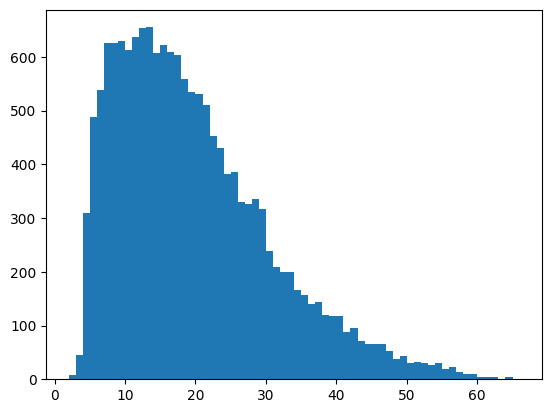

In [74]:
# Calculate lengths of tweets (in words)
lengths = [len(t.split(' ')) for t in tweets]

# Plot histogram of tweet lengths
plt.hist(lengths, bins=len(set(lengths)))
plt.show()

In [75]:
# Set maximum sequence length
maxlen = 50

from tensorflow.keras.preprocessing.sequence import pad_sequences

In [76]:
# Function to convert tweets to padded sequences
def get_sequences(tokenizer, tweets):
    sequences = tokenizer.texts_to_sequences(tweets)
    padded = pad_sequences(
        sequences,
        truncating='post',
        padding='post',
        maxlen=maxlen
    )
    return padded

In [77]:
# Get padded training sequences
padded_train_seq = get_sequences(tokenizer, tweets)

In [78]:
# View first padded sequence
padded_train_seq[0]

array([  2, 139,   3, 679,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0], dtype=int32)

## Task 5: Preparing the Labels

1. Creating classes to index and index to classes dictionaries
2. Converting text labels to numeric labels

In [79]:
# Get unique classes
classes = train.features['label'].names
print(classes)

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


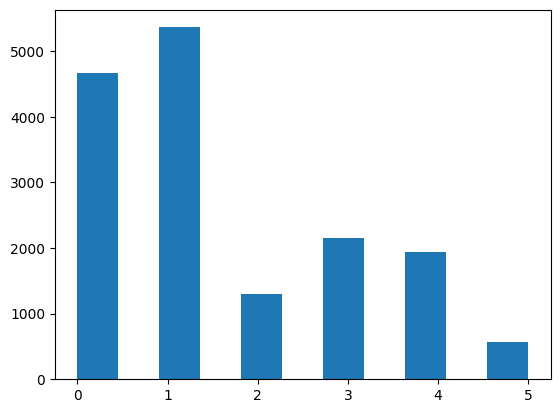

In [80]:
# Plot label distribution
plt.hist(labels, bins=11)
plt.show()

In [88]:
# Create mappings between class names and indices
class_to_index = dict((c, i) for i, c in enumerate(classes))
index_to_class = dict((v, k) for k, v in class_to_index.items())

In [89]:
class_to_index

{'sadness': 0, 'joy': 1, 'love': 2, 'anger': 3, 'fear': 4, 'surprise': 5}

In [90]:
index_to_class

{0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}

In [91]:
# Convert label names to numeric IDs
names_to_ids = lambda labels: np.array([class_to_index.get(x) for x in labels])

In [94]:
# Convert training labels
train_labels = np.array(labels)

# Example
print(train_labels[0])

0


## Task 6: Creating the Model

1. Creating the model
2. Compiling the model

In [100]:
# Build the model
model = tf.keras.models.Sequential([
    tf.keras.layers.Embedding(10000, 16),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(20, return_sequences=True)),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(20)),
    tf.keras.layers.Dense(6, activation='softmax')
])

# Compile the model
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [101]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Task 7: Training the Model

1. Preparing a validation set
2. Training the model

In [102]:
# Get validation data
val_tweets, val_labels = get_tweet(val)
val_seq = get_sequences(tokenizer, val_tweets)

# Labels are already numeric — no conversion needed
val_labels = np.array(val_labels)

In [103]:
# Check sample
val_tweets[0], val_labels[0]

('im feeling quite sad and sorry for myself but ill snap out of it soon',
 np.int64(0))

In [104]:
# Train model
h = model.fit(
    padded_train_seq, train_labels,
    validation_data=(val_seq, val_labels),
    epochs=20,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=2)
    ]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 17s 16ms/step - accuracy: 0.4846 - loss: 1.2932 - val_accuracy: 0.7110 - val_loss: 0.7846
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.8061 - loss: 0.5474 - val_accuracy: 0.8165 - val_loss: 0.5499
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.8916 - loss: 0.3248 - val_accuracy: 0.8475 - val_loss: 0.4252
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9261 - loss: 0.2258 - val_accuracy: 0.8690 - val_loss: 0.4221
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9453 - loss: 0.1748 - val_accuracy: 0.8735 - val_loss: 0.3862
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9609 - loss: 0.1291 - val_accuracy: 0.8800 - val_loss: 0.3961
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9686 - loss: 0.1013 - val_accuracy: 0.8920 - val_loss: 0.3982
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9743 - loss: 0.0805 - val_ac

## Task 8: Evaluating the Model

1. Visualizing training history
2. Prepraring a test set
3. A look at individual predictions on the test set
4. A look at all predictions on the test set

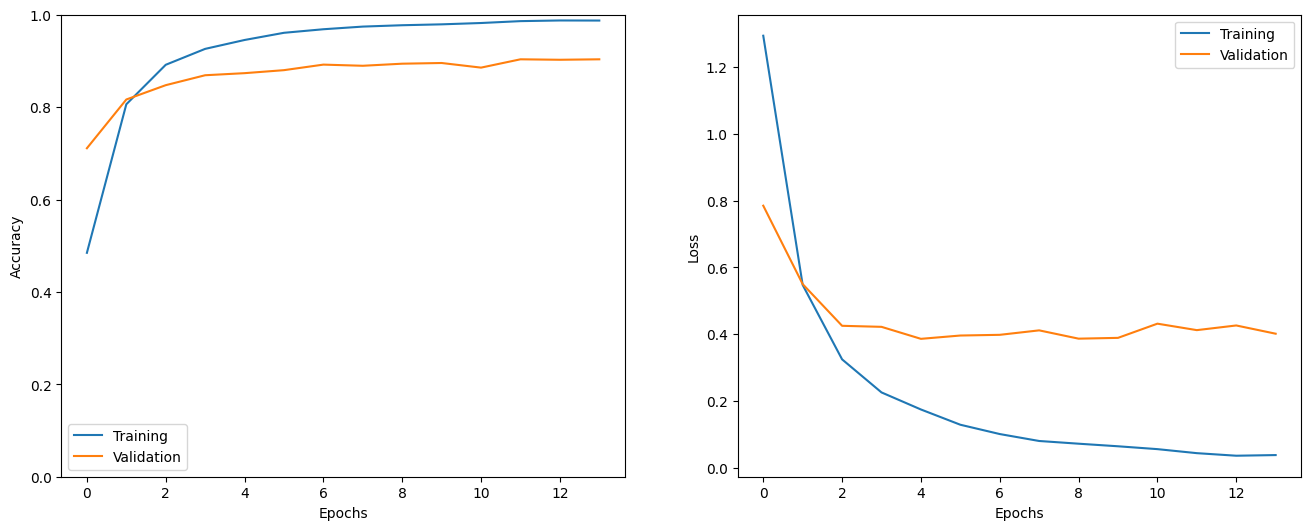

In [105]:
show_history(h)

In [108]:
# Get test data
test_tweets, test_labels = get_tweet(test)
test_seq = get_sequences(tokenizer, test_tweets)
test_labels = np.array(test_labels)

In [109]:
# Evaluate model
_ = model.evaluate(test_seq, test_labels)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8860 - loss: 0.4346


In [112]:
# Pick a random sample
i = random.randint(0, len(test_labels) - 1)

print('Sentence:', test_tweets[i])
print('Emotion:', index_to_class[test_labels[i]])

# Predict
p = model.predict(np.expand_dims(test_seq[i], axis=0))[0]
pred_class = index_to_class[np.argmax(p)]

print('Predicted Emotion:', pred_class)

Sentence: i get the feeling donald is smart enough to educate himself through his own densely focused meanderings and their inherent shortcomings
Emotion: joy
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Predicted Emotion: joy


In [116]:
preds = np.argmax(model.predict(test_seq), axis=-1)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


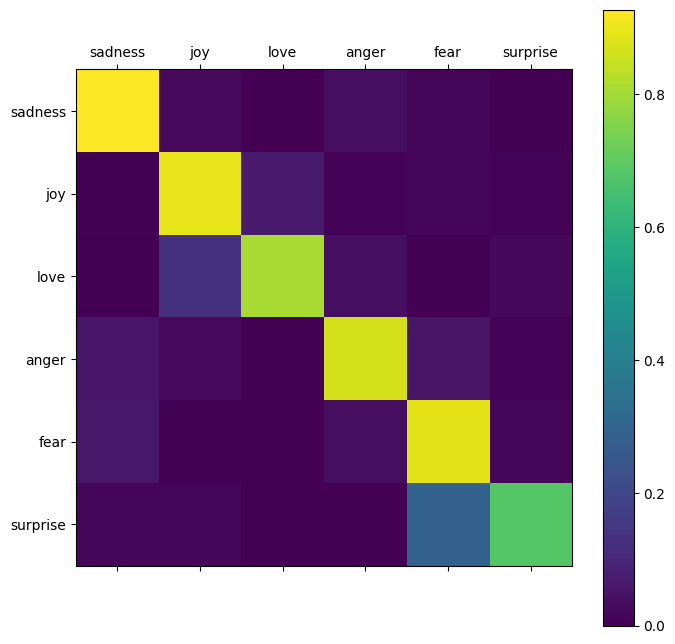

In [118]:
show_confusion_matrix(test_labels, preds, list(classes))